# Machine Learning 2025W — Exercise 1  
### Dataset Description and Exploration (heart disease)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
import ssl
import certifi
import itertools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree


ssl_context = ssl.create_default_context(cafile=certifi.where())

pd.set_option('display.max_columns', None)


## 2. Load Dataset

In [ ]:
# Fetch dataset by ID (45 = Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Split into features (X) and target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine for convenience
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
df.head()

## 3. Basic Information

In [ ]:
df.info()
df.describe()
df.isna().sum()

## 4. Target Variable

In [ ]:
target_col = 'num' 
sns.countplot(x=target_col, data=df)
plt.title('Presence of heart disease (target)')
plt.xlabel('Heart Disease Presence (num)')
plt.show()


## 5. Feature Exploration

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
corr = df.corr(numeric_only=True)['num'].sort_values(ascending=False)
corr

# Preprocessing

## Preprocess Target variable

In [ ]:
def target_bin(x):
    if x>0:
        return 1
    else:
        return 0

df["num"]= df["num"].apply(target_bin) # we binarize the target variable (1= presenze of a heart diseas, 0= not present)
df["diagnosis"]= df["num"] # rename target variable to "diagnosis"
df= df.drop(["num"], axis=1)
df.head()
target_col = 'diagnosis' 
sns.countplot(x=target_col, data=df)
plt.title('Presence of heart disease (target)')
plt.xlabel('Heart Disease Presence (diagnosis)')
plt.show()


### Preprocess Input variables

#### Check for outliers

In [ ]:
plt.figure()
plt.boxplot(df["age"])
plt.title("age") # no outliers

plt.figure()
plt.boxplot(df["trestbps"]) # expected range [90-200]
plt.title("trestbps") # no outliers

plt.figure()
plt.boxplot(df["chol"]) # expect range [100- max 400]
plt.title("chol") # here we can see some outliers which have to be handeled

plt.figure()
plt.boxplot(df["thalach"]) # expected range [80-200]
plt.title("thalach") # no clear outliers here

plt.figure()
plt.boxplot(df["oldpeak"]) # expected range [0-5]
plt.title("oldpeak") # we can see here some upper outliers which have to be handeld

plt.figure()
plt.boxplot(df["ca"].dropna()) # expected range [0-3]
plt.title("ca") # no outliers


In [ ]:
def handle_chol(x): #Cap values a 500 since more extreme values are very unlikly and would highly influence our model
    if x>500:
        return 500
    else:
        return x

def handle_oldpeak(x): #Cap values a 5.5 since more extreme values are very unlikly and would highly influence our model
    if x>5.5:
        return 5.5
    else:
        return x

df["chol"]= df["chol"].apply(handle_chol)
df["oldpeak"]= df["oldpeak"].apply(handle_oldpeak)

# check again visually for outliers
plt.figure()
plt.boxplot(df["chol"]) # expect range [100- max 400]
plt.title("chol") # here we can see some outliers which have to be handeled


plt.figure()
plt.boxplot(df["oldpeak"]) # expected range [0-5]
plt.title("oldpeak") # we can see here some upper outliers which have to be handeld

### Handle missing values

In [ ]:
contains_value = (df == '?').any().any()
contains_value #check if ther are any ? which could be potential null values

In [ ]:
pd.isna(df).any()


In [ ]:
df[pd.isna(df).any(axis=1)]

Here we can see that there are some missing values in the ca and thal columns. By inspecting the dataset we can see no logical meaningful reason for the NA values.

In [ ]:
print("Number of NA values in ca:")
print(df["ca"].isna().sum())
print("Number of NA values in thal:")
print(df["thal"].isna().sum())

We see that there are 4 missing values in the ca column and 2 missing values in the thal column. That are quite few, thats why we decided to just drop the rows with missing values.

In [ ]:
df=df.dropna(subset=["ca","thal"])
pd.isna(df).any()


### Split data into train and test sets

In [ ]:
X = df.drop("diagnosis", axis=1)  # features
y = df["diagnosis"]               # diagnosis

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% of data for testing
    random_state=42,     # ensures reproducibility
    stratify=y           # keeps same class proportions in train/test
)

y_train.head()

### Making a scaled dataset

In [ ]:
X_train_scaled=X_train.copy()
X_test_scaled= X_test.copy()
scaler = StandardScaler()
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] # scale all numerical values exept ca
X_train_scaled[numeric_cols]= scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols]= scaler.fit_transform(X_test_scaled[numeric_cols])
X_test_scaled.describe()

We now have scaled X in two new datasets all numerical values with a standard scaler such that mean is 0 and standard deviation is 1. WE have not included ca in the scalling since it only takes the values 0,1,2,3 and thus it would make a real difference to scale.

# Model Training and Evaluation

We train three classifiers — Decision Tree, KNN, and Naive Bayes — and check how well they predict loan grades.

## Decision Tree Classifier

In [ ]:

# Hyperparameter lists
max_depths = [2,3,5,10, None]
min_splits = [2,3,5,10]
min_leafs = [3,5, 10]
criterions = ["gini", "entropy"]
weights = [None, "balanced"]

results = []

# Loop through all combinations
for depth, split, leaf, crit, weight in itertools.product(max_depths, min_splits, min_leafs, criterions, weights):
    
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        criterion=crit,
        class_weight=weight,
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]  # probability for AUC
    
    results.append({
        "max_depth": depth,
        "min_samples_split": split,
        "min_samples_leaf": leaf,
        "criterion": crit,
        "class_weight": str(weight),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average='macro'),
        "weighted_f1": f1_score(y_test, y_pred, average='weighted'),
        "auc": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
res_df_ordered= results_df.copy()
res_df_ordered.sort_values(by="macro_f1", ascending=False, inplace=True)
res_df_ordered = res_df_ordered.set_index(["class_weight","criterion","max_depth","min_samples_split","min_samples_leaf"])
res_df_ordered= res_df_ordered.sort_index()
res_df_ordered.head(50)

In [ ]:
# Plots for visualization

## Headmap for the differnt min/max values:
leaf_values = sorted(results_df["min_samples_leaf"].unique())

# Create a single figure with 1 row and N columns (one subplot per leaf value)
fig, axes = plt.subplots(1, len(leaf_values), figsize=(6 * len(leaf_values), 4), sharey=True)

for ax, leaf in zip(axes, leaf_values):
    subset = results_df[results_df["min_samples_leaf"] == leaf]
    heatmap_data = subset.pivot_table(
        values="macro_f1",
        index="max_depth",
        columns="min_samples_split"
    )
    
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"min_samples_leaf = {leaf}")
    ax.set_xlabel("min_samples_split")
    ax.set_ylabel("max_depth")

plt.suptitle("Macro F1 by max_depth and min_samples_split for different min_samples_leaf values", y=1.05)
plt.tight_layout()
plt.show()


## Bar chart to show the effect of differnt criterions
sns.barplot(x='class_weight', y='macro_f1', hue='criterion', data=results_df)
plt.title("Effect of class_weight and criterion on Macro F1")
plt.show()

## Plot to show the influnce of weighting the classes
sns.scatterplot(x='weighted_f1', y='macro_f1', hue='class_weight', style='criterion', data=results_df)
plt.title("Weighted F1 vs Macro F1 across Decision Tree variants (class_weight)")
plt.show()



We numerically search the best model dependent on the various evaluation metrics (macro_f1, weighted_f1, accuracy, auc).:

In [ ]:
# Choose the best combination of hyper paramters model:
hyperparams = ["max_depth","min_samples_split","min_samples_leaf","criterion","class_weight"]
# Pick the row with the highest Macro F1
best_model = results_df.loc[results_df['macro_f1'].idxmax()]

print("Optimal hyperparameter combination based on Macro F1:")
print(best_model[hyperparams])

# Pick the row with the highest weighted_f1
best_model = results_df.loc[results_df['weighted_f1'].idxmax()]

print("Optimal hyperparameter combination based on weighted_f1:")
print(best_model[hyperparams])

# Pick the row with the highest accuracy
best_model = results_df.loc[results_df['accuracy'].idxmax()]

print("Optimal hyperparameter combination based on accuracy:")
print(best_model[hyperparams])

# Pick the row with the highest auc
best_model = results_df.loc[results_df['auc'].idxmax()]

print("Optimal hyperparameter combination based on auc:")
print(best_model[hyperparams])


We fit the choosen best model and look what the most importnat features are:

In [ ]:
# Fit the evaluated optical model and get the most important attributes
clf_best = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    criterion="gini",
    class_weight=None,
    random_state=42
)

clf_best.fit(X_train, y_train)

# Get feature importances
importances = clf_best.feature_importances_

# Combine with feature names
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top important features:")
print(feature_importance_df.head(10)) 

We compare the evaluation metrics for the unscaled and scaled dataset:

In [ ]:
#Resulting evaulation values for the best selected model
test_pred = clf_best.predict(X_test)

print("Classification report for the UNSCALED data: ")
print(classification_report(y_test, test_pred))


# Apply the best model on the scaled data (shoulnt make any big difference)
clf_best_scaled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    criterion="gini",
    class_weight=None,
    random_state=42
)

clf_best_scaled.fit(X_train_scaled, y_train)

test_pred_scaled = clf_best_scaled.predict(X_test_scaled)

print("Classification report for the SCALED data: ")
print(classification_report(y_test, test_pred_scaled))

In [ ]:

plt.figure(figsize=(20, 10))
plot_tree(
    clf_best,
    filled=True,
    rounded=True,
    class_names=[str(cls) for cls in clf_best.classes_],
    feature_names=X_train.columns,
    fontsize=10
)
plt.title("Decision Tree (Best Model)")
plt.show()

# K-NN

## k-NN Base model

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Scale them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# 3. Determine optimal k = sqrt(n)
k = int(np.sqrt(len(X_train_numeric)))
if k % 2 == 0:
    k += 1
print(f"Using k = {k}")

# 4. Train, predict, and measure runtime
start_unscaled = time.time()
knn_unscaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_unscaled.fit(X_train_numeric, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test_numeric)
y_prob_unscaled = knn_unscaled.predict_proba(X_test_numeric)
time_unscaled = time.time() - start_unscaled

start_scaled = time.time()
knn_scaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
y_prob_scaled = knn_scaled.predict_proba(X_test_scaled)
time_scaled = time.time() - start_scaled

# 5. Evaluate
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob[:, 1])  # use probability of positive class
    }

scores_unscaled = evaluate(y_test, y_pred_unscaled, y_prob_unscaled)
scores_scaled = evaluate(y_test, y_pred_scaled, y_prob_scaled)

# 6. Display results
print("\nUnscaled performance:")
for metric, value in scores_unscaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_unscaled:.3f} seconds")

print("\nScaled performance:")
for metric, value in scores_scaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_scaled:.3f} seconds")


Using k = 15

Unscaled performance:
Accuracy  : 0.7167
Precision : 0.7200
Recall    : 0.6429
F1        : 0.6792
ROC AUC   : 0.8108
Runtime   : 0.004 seconds

Scaled performance:
Accuracy  : 0.8500
Precision : 0.8800
Recall    : 0.7857
F1        : 0.8302
ROC AUC   : 0.9609
Runtime   : 0.001 seconds


## Remove high correlarity

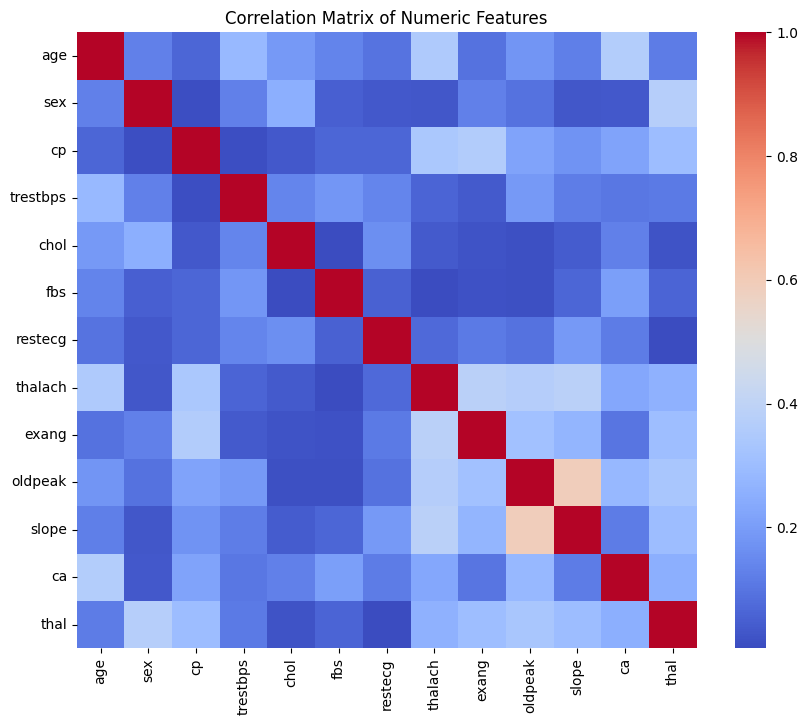

Removed features: []
Accuracy (unscaled): 0.7167
Accuracy (scaled):   0.8500


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Compute correlation matrix and remove highly correlated features
corr_matrix = X_train_numeric.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop columns with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_reduced = X_train_numeric.drop(columns=to_drop)
X_test_reduced = X_test_numeric.drop(columns=to_drop, errors='ignore')

# Show correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# 3. Scale remaining features
scaler = StandardScaler()
X_train_scaled_reduced = scaler.fit_transform(X_train_reduced)
X_test_scaled_reduced = scaler.transform(X_test_reduced)

# 4. Train and compare
knn_unscaled = KNeighborsClassifier(n_neighbors=k)
knn_unscaled.fit(X_train_reduced, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test_reduced))

knn_scaled = KNeighborsClassifier(n_neighbors=k)
knn_scaled.fit(X_train_scaled_reduced, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled_reduced))

print(f"Removed features: {to_drop}")
print(f"Accuracy (unscaled): {acc_unscaled:.4f}")
print(f"Accuracy (scaled):   {acc_scaled:.4f}")


### Subset

         subset  n_features  accuracy  runtime_sec
0  1/3 features           4  0.666667     0.001424
1  2/3 features           8  0.666667     0.000794
2  All features          13  0.700000     0.001116


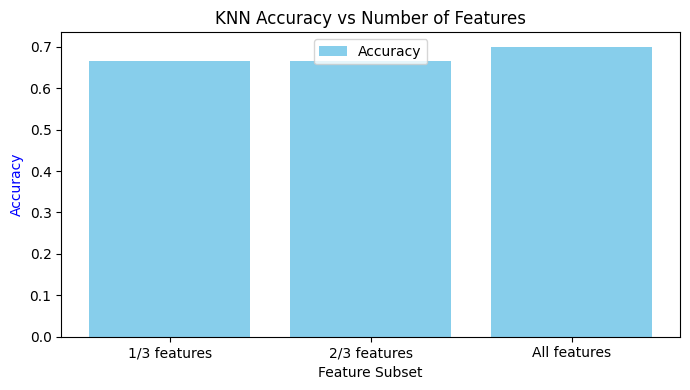

In [ ]:
import numpy as np, time
from time import perf_counter
from sklearn.neighbors import KNeighborsClassifier

subset_sizes  = [X.shape[1]//3, 2*X.shape[1]//3, X.shape[1]]
subset_labels = ['1/3 features','2/3 features','All features']

results = []
for size, label in zip(subset_sizes, subset_labels):
    Xtr = X_train.iloc[:, :size].to_numpy(dtype=np.float32)
    Xte = X_test.iloc[:,  :size].to_numpy(dtype=np.float32)

    knn = KNeighborsClassifier(n_neighbors=5, algorithm='brute', n_jobs=1)
    knn.fit(Xtr, y_train)

    # warm-up
    _ = knn.predict(Xte[:5])

    # repeat predicts and take median
    reps, times = 20, []
    for _ in range(reps):
        t0 = perf_counter()
        _ = knn.predict(Xte)
        times.append(perf_counter() - t0)
    runtime = float(np.median(times))

    acc = (knn.predict(Xte) == y_test).mean()
    results.append({'subset': label, 'n_features': size,
                    'accuracy': acc, 'runtime_sec': runtime})


# Display results
df = pd.DataFrame(results)
print(df)

# --- Visualization (Accuracy only) ---
plt.figure(figsize=(7,4))
plt.bar(df['subset'], df['accuracy'], color='skyblue', label='Accuracy')

plt.xlabel('Feature Subset')
plt.ylabel('Accuracy', color='blue')
plt.title('KNN Accuracy vs Number of Features')
plt.legend(loc='upper center')

plt.tight_layout()
plt.show()


## Best Model

In [ ]:
from sklearn.model_selection import GridSearchCV
# Base model
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 15, 21, 33, 47],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}

# Grid search with 5-fold cross-validation
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Results
print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Evaluate on test set
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.7001773049645389
Test accuracy: 0.8


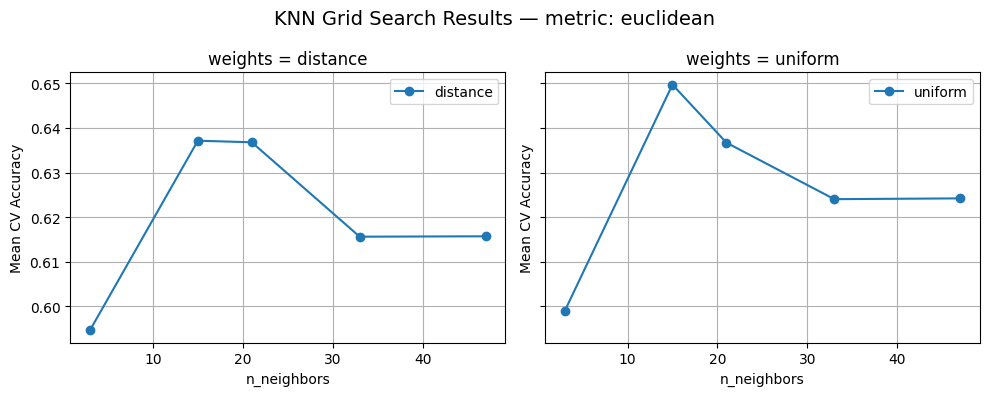

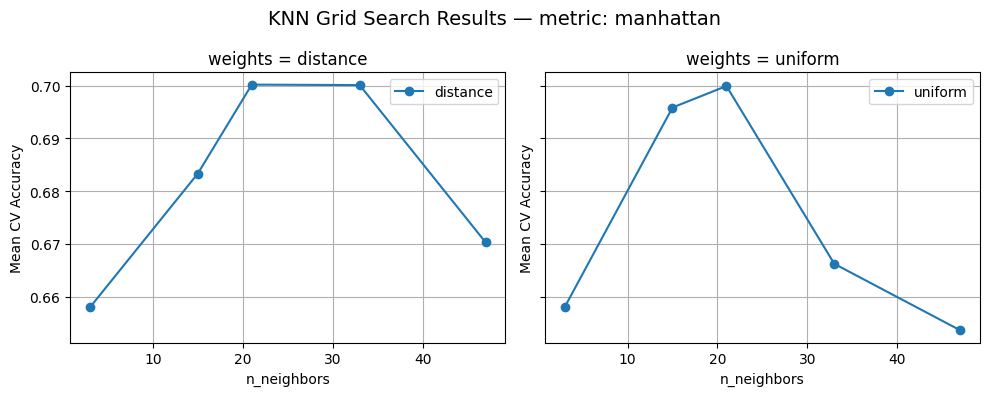

In [ ]:
# ---- Grid Search Visualization ----
results = grid.cv_results_
k_values = sorted(list(set(results['param_n_neighbors'])))
weights = sorted(list(set(results['param_weights'])))
metrics = sorted(list(set(results['param_metric'])))

for metric in metrics:
    fig, axes = plt.subplots(1, len(weights), figsize=(10, 4), sharey=True)
    fig.suptitle(f"KNN Grid Search Results — metric: {metric}", fontsize=14)

    for i, weight in enumerate(weights):
        # Collect mean CV accuracies for each k
        scores = []
        for k in k_values:
            mask = (results['param_n_neighbors'] == k) & \
                   (results['param_metric'] == metric) & \
                   (results['param_weights'] == weight)
            mean_score = np.mean(results['mean_test_score'][mask])
            scores.append(mean_score)

        axes[i].plot(k_values, scores, marker='o', label=f'{weight}')
        axes[i].set_title(f'weights = {weight}')
        axes[i].set_xlabel('n_neighbors')
        axes[i].set_ylabel('Mean CV Accuracy')
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

## Decision Tree Classifier

In [ ]:
# Create and train the model
clf = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=20,   # Minimum samples required to split a node
    random_state=42
)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

In [ ]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# View feature importance
# View feature importance
print("\nTop 10 most important features:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))


Accuracy: 0.73

Top 10 most important features:
     feature  importance
12      thal    0.439218
2         cp    0.258917
9    oldpeak    0.092371
4       chol    0.074044
11        ca    0.068999
3   trestbps    0.038065
0        age    0.028385
1        sex    0.000000
5        fbs    0.000000
6    restecg    0.000000


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid to search - Option 1 with aggressive pruning
param_grid = {
    'max_depth': [3, 5, 7],  # Try even shallower trees
    'min_samples_split': [30, 50, 100],  # More aggressive
    'min_samples_leaf': [10, 15, 20, 25],  # Larger leaves
    'ccp_alpha': [0.001, 0.005, 0.01, 0.02, 0.05],  # Pruning parameter
    'criterion': ['entropy']
}

# Create the model
clf = DecisionTreeClassifier(random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # or 'f1', 'roc_auc', etc.
    n_jobs=-1,              # Use all CPU cores
    verbose=2
)

# Fit the grid search
print("Starting grid search...")
grid_search.fit(X_train, y_train)

# Get the best parameters
print("\n" + "="*50)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
print("="*50)

# Use the best model
best_clf = grid_search.best_estimator_

# Predictions
train_pred = best_clf.predict(X_train)
y_pred = best_clf.predict(X_test)

# Evaluate
print("\nPerformance metrics:")
print(f"Train accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"CV accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Train-Test gap: {accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred):.4f}")

Starting grid search...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=30; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=50; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=50; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=100; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=30; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=100; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_leaf=10, min_samples_split=30; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=3, min_samples_l

In [ ]:
# 1. Check train accuracy
train_pred = best_clf.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("CV accuracy:", 0.8137)
print("Test accuracy:", 0.7667)

# 2. Check class distribution
print("\nClass distribution in train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test:")
print(y_test.value_counts(normalize=True))

# 3. Look at detailed metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train accuracy: 0.8396624472573839
CV accuracy: 0.8137
Test accuracy: 0.7667

Class distribution in train:
diagnosis
0    0.540084
1    0.459916
Name: proportion, dtype: float64

Class distribution in test:
diagnosis
0    0.533333
1    0.466667
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        32
           1       0.83      0.71      0.77        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60

